# idek what to call this yes
Interested in DEGs identified in oysters sampled after phase 1, and how the expression of those genes change in oysters from phase 2

## 0. load libraries

In [2]:
library(tidyverse)

## 1. read in CSVs

### oysters sampled after phase 1
#### DEGs only

In [5]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- gsub("^DEG_", "", tools::file_path_sans_ext(basename(files)))
deg_list <- lapply(files, read.csv)
names(deg_list)
head(deg_list$b_c)

[1] "b_c" "h_b" "h_c" "h_w" "w_b" "w_c"

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC111119645,653.22102,-5.020538,2.441757,-4.024549,5.708460e-05,1.196733e-02,2.961309e-02,C vs. B,C
2,LOC111111234,734.07909,-1.798884,1.216529,-3.763521,1.675379e-04,2.586952e-02,6.637397e-02,C vs. B,C
3,LOC111104630,30.39451,1.701065,1.638795,3.500313,4.647117e-04,4.910747e-02,1.288707e-01,C vs. B,B
4,LOC111129171,35.65903,-20.575402,4.241105,-5.271934,1.349937e-07,8.337208e-05,2.209650e-04,C vs. B,C
5,LOC111121183,21.46042,21.131265,3.106873,6.986352,2.821259e-12,5.808033e-09,1.007325e-08,C vs. B,B
6,LOC111111721,37.95811,-4.710274,1.156190,-4.669312,3.022105e-06,1.278392e-03,1.662824e-03,C vs. B,C


and then just in case I want vst expression for these oysters later:

In [7]:
p1.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.both_v_cont.csv') %>%
select(-1, -3:-9)
head(p1.vst)

,Gene,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,0.8524235,15.240013,10.874293,12.37254,1.041203,13.946695,2.142553,1.049389,1.535909,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,555.7800963,498.157926,371.398937,1617.42906,634.092462,457.625927,1152.693402,567.719691,434.662227,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,178.1565033,168.592644,173.152207,173.21563,191.581302,129.006928,154.263801,168.951701,119.032942,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,5.9669642,1.905002,8.364841,21.37076,18.741649,9.588353,18.211699,22.037178,13.823180,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,499.5201479,397.192840,324.555827,227.20492,343.596901,739.174830,252.821229,163.704754,536.800171,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.142553,4.197558,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


### oysters sampled after phase 2
I think for this I only need vst ... (and all genes, not just DEGs)

In [9]:
p2.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/all_genes/bc_hc.csv') %>%
select(-2:-8) # remove the deseq junk
head(p2.vst)

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,1.875059,5.965799,9.44740,7.830485,0.00000,11.75544,14.436329,9.311552,7.673523,⋯,4.336105,2.452846,11.19491,2.006592,7.359253,5.277065,2.300668,21.05700,1.075999,0.0000
2,LOC111126949,829.713451,474.281013,617.85999,509.851567,453.26645,419.66928,325.473593,558.693109,621.555373,⋯,230.897604,544.531781,506.25864,742.439160,650.373981,428.497663,480.839693,469.90350,302.355713,636.4963
3,LOC111110729,60.001877,92.469883,59.51862,87.005387,87.87819,115.20333,154.206239,187.265653,97.563365,⋯,128.999131,62.138762,87.07151,149.491128,111.308701,121.372491,144.942108,119.69240,136.651870,226.3334
4,LOC111112434,10.312823,1.988600,0.00000,1.740108,13.87550,17.63316,6.561968,37.246207,1.096218,⋯,6.504158,0.000000,13.68267,6.019777,3.679626,0.000000,2.300668,17.73221,8.607992,0.0000
5,LOC111120752,337.510556,334.084739,402.45926,305.388908,272.88491,326.80129,499.365735,385.912092,202.800254,⋯,421.686235,286.165350,446.55246,346.137176,402.919100,293.404804,330.145914,461.03739,358.307660,456.9172
6,LOC111128944,0.000000,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,⋯,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000


### meta data

In [18]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
mutate(combo = paste(Phase1_treatment, Phase2_treatment, sep='_'))
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA,both_NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA,both_NA


## 2. pull out genes of interest

### phase 1 hypoxic vs. control DEGs

In [64]:
hc.deg <- deg_list$h_c %>%
mutate(reg_dir = ifelse(
    log2FoldChange > 1, 'upregulated in p1 oys', 'downregulated in p1 oys'))

dim(hc.deg) # 51 total DEGs
head(hc.deg)

# verify this works
hc.deg %>%
count(reg_dir)

[1] 51 11

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,pair,DEG_group,reg_dir
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111121183,21.46042,15.211740,3.156865,5.166942,2.379552e-07,2.844159e-04,5.335314e-04,C vs. H,H,upregulated in p1 oys
2,LOC111120021,13.26161,18.085911,3.199446,5.819812,5.891377e-09,1.314445e-05,3.269501e-05,C vs. H,H,upregulated in p1 oys
3,LOC111119724,15.13209,21.128405,3.942859,5.619105,1.919492e-08,3.381033e-05,1.031286e-04,C vs. H,H,upregulated in p1 oys
4,LOC111119726,13.84327,21.147479,3.942362,5.624029,1.865544e-08,3.381033e-05,9.425773e-05,C vs. H,H,upregulated in p1 oys
5,LOC111125414,1018.22362,6.494957,1.945575,4.704799,2.541167e-06,2.743395e-03,2.862712e-03,C vs. H,H,upregulated in p1 oys
6,LOC111123780,1160.93597,7.692322,1.409322,5.578092,2.431712e-08,4.069106e-05,1.317082e-04,C vs. H,H,upregulated in p1 oys


reg_dir,n
<chr>,<int>
downregulated in p1 oys,22
upregulated in p1 oys,29


In [75]:
phase2oys_hc.deg <- p2.vst[p2.vst$Gene %in% hc.deg$X,] %>%
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst'
    ) %>%
merge(meta, by = 'Sample') %>%
# only want control and hypoxic samples rn
filter(!Phase1_treatment %in% c('warm', 'both') &
         !Phase2_treatment %in% c('warm', 'both'))

phase2oys_hc.deg <- cbind(phase2oys_hc.deg, hc.deg) %>%
select(c(-13:-22))

head(phase2oys_hc.deg)

,Sample,Gene,vst,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo,reg_dir
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,C1_C4_W37,LOC111112191,165.692801,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,upregulated in p1 oys
2,C1_C4_W37,LOC111117306,18.904548,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,upregulated in p1 oys
3,C1_C4_W37,LOC111134915,3.336097,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,upregulated in p1 oys
4,C1_C4_W37,LOC111117789,7.784226,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,upregulated in p1 oys
5,C1_C4_W37,LOC111125414,0.000000,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,upregulated in p1 oys
6,C1_C4_W37,LOC111132199,123.435577,control,ambient,normoxic,1,control,ambient,normoxic,4,control_control,upregulated in p1 oys


Warning message:
“Removed 28 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


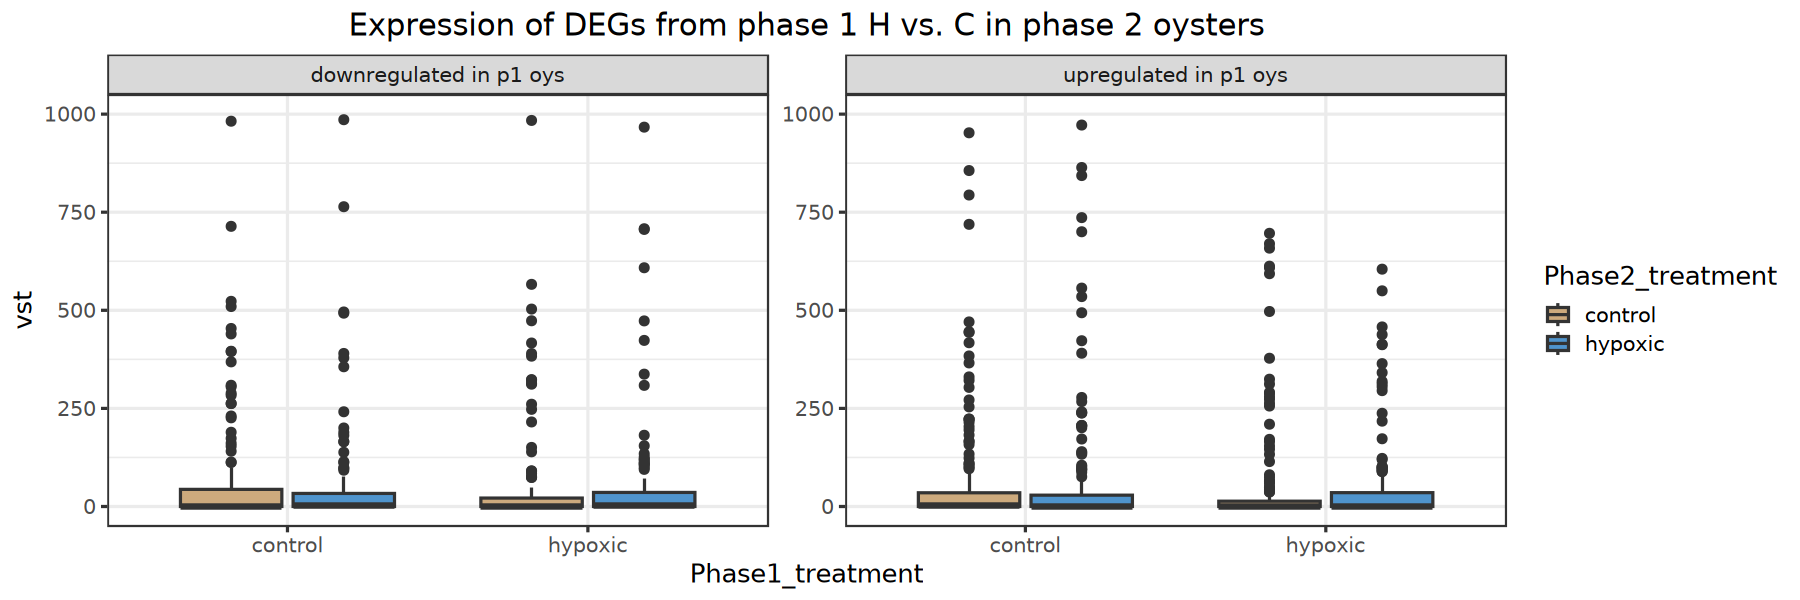

In [72]:
options(repr.plot.height = 5, repr.plot.width = 15)

ggplot(phase2oys_hc.deg, aes(x = Phase1_treatment, y = vst, fill = Phase2_treatment)) +
geom_boxplot() +
facet_wrap(~reg_dir, scales = 'free') + 
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
labs(title = 'Expression of DEGs from phase 1 H vs. C in phase 2 oysters') +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) +
# reducing yaxis just to see if we can see more
# removes 28 genes (which is about half of the data ...)
ylim(c(0,1000)) 

maybe its better to look at mean +- se? since it appears there's a lot of genes/samples with 0 expression for this gene set

In [49]:
p2oys_hc <- phase2oys_hc.deg %>%
group_by(Gene, combo, reg_dir) %>%
summarise(meanExp = mean(vst),
         seExp = sd(vst) / sqrt(n()), # standard error
         ) %>%
separate(col = combo, into = c('phase1', 'phase2'), sep = '_')

head(p2oys_hc)

`summarise()` has grouped output by 'Gene', 'combo'. You can override using the
`.groups` argument.


Gene,phase1,phase2,reg_dir,meanExp,seExp
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
LOC111100009,both,both,downregulated,0.4723700,0.4723700
LOC111100009,both,both,upregulated,26.6524137,26.6524137
LOC111100009,both,control,downregulated,0.0000000,NA
LOC111100009,both,control,upregulated,0.2938861,0.2938861
LOC111100009,both,hypoxic,downregulated,236.7447288,236.7447288
LOC111100009,both,hypoxic,upregulated,491.8047804,275.8123256


In [56]:
# reorder axes
p2oys_hc$phase1 <- factor(p2oys_hc$phase1, levels = c('control', 'warm', 'hypoxic', 'both'))
p2oys_hc$phase2 <- factor(p2oys_hc$phase2, levels = c('control', 'warm', 'hypoxic', 'both'))

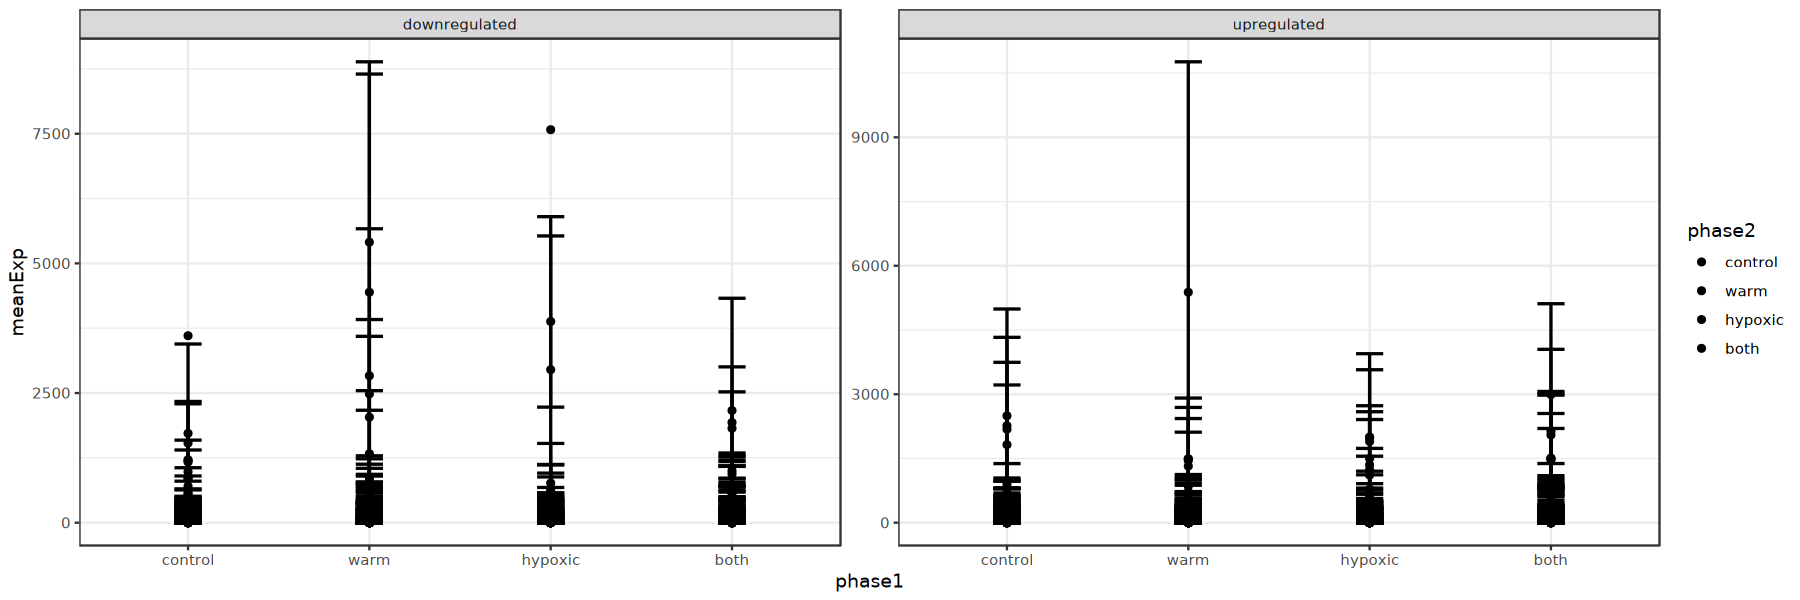

In [57]:
ggplot(p2oys_hc, aes(x = phase1, y = meanExp, fill = phase2)) +
geom_point() +
facet_wrap(~reg_dir, scales = 'free') + 
geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
scale_fill_manual(values = c("control" = "burlywood3", "hypoxic" = "steelblue3", "warm" = "palevioletred", "both" = "plum3")) + 
theme_bw()

#### two-way ANOVA

In [77]:
mod <- aov(vst ~ Phase1_DO *  Phase2_DO, 
    data = phase2oys_hc.deg)

summary(mod)

                      Df    Sum Sq Mean Sq F value Pr(>F)
Phase1_DO              1     16314   16314   0.053  0.817
Phase2_DO              1     62065   62065   0.203  0.652
Phase1_DO:Phase2_DO    1     87627   87627   0.287  0.592
Residuals           1169 356567661  305019               

don't see an effect of DO on the expression of these phase 1 DEGs